In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from geometry import *
from event_detector import *

CSV_FOLDER = Path(r"C:\Users\david\Documents\TFG\data_csv") 

all_files = sorted(list(CSV_FOLDER.glob('*.csv')))

print(f"There are {len(all_files)} files.")

There are 347 files.


In [7]:
kick_platform = [f for f in all_files if 'kick' in f.name.lower() and 'platform' in f.name.lower()][:8]
kicK_pinpoint = [f for f in all_files if 'kick' in f.name.lower() and 'pinpoint' in f.name.lower()][:8]

slice_platform = [f for f in all_files if 'slice' in f.name.lower() and 'platform' in f.name.lower()][:8]
slice_pinpoint = [f for f in all_files if 'slice' in f.name.lower() and 'pinpoint' in f.name.lower()][:8]

flat_platform = [f for f in all_files if 'flat' in f.name.lower() and 'platform' in f.name.lower()][:8]
flat_pinpoint = [f for f in all_files if 'flat' in f.name.lower() and 'pinpoint' in f.name.lower()][:8]

kick_files =  kick_platform + kicK_pinpoint
slice_files = slice_platform + slice_pinpoint
flat_files = flat_platform + flat_pinpoint

selected_files = kick_files + slice_files + flat_files
len(selected_files)

48

In [43]:
def calculate_knee_frame(df):
    angles_knee = [calculate_angles(
            [row.LEFT_HIP_x, row.LEFT_HIP_y], 
            [row.LEFT_KNEE_x, row.LEFT_KNEE_y], 
            [row.LEFT_ANKLE_x, row.LEFT_ANKLE_y]
            ) for _, row in df.iterrows()]
    start, min_f, max_f, target_f = detectar_fases_saque(angles_knee)
    return start, min_f, max_f, target_f

# VAMOS A ANALIZAR EL ANGULO DEL HOMBRO EN LOS 3 TIPOS DE STANCE

In [16]:
def analyze_shoulder_inclination(df, start, max_frame):
    end_limit = min(max_frame + 20, len(df) - 1)
    
    # We look for the heighest point of the wrist
    # Is the min because in meadiapipe that means the max point in the screen
    impact_frame = df.loc[start:end_limit, 'RIGHT_WRIST_y'].idxmin()
    
    shoulder_angles = []
    frames = range(start, max_frame+20)
    
    for i in frames:
        if i >= len(df): break
        
        head = [df.loc[i, 'NOSE_x'], df.loc[i, 'NOSE_y']]
        shoulder = [df.loc[i, 'RIGHT_SHOULDER_x'], df.loc[i, 'RIGHT_SHOULDER_y']]
        hip = [df.loc[i, 'RIGHT_HIP_x'], df.loc[i, 'RIGHT_HIP_y']]
        
        ang = calculate_angles(head, shoulder, hip)
        shoulder_angles.append(ang)
        
    return list(frames), shoulder_angles, impact_frame

In [23]:
def analyze_shoulder_inclination(df, start, max_frame):
    # 1. Definimos el límite real para no salirnos del archivo
    end_limit = min(max_frame + 20, len(df) - 1)
    
    # 2. Buscamos el impacto (Punto más alto de la muñeca) en el rango válido
    # Usamos idxmin() porque en MediaPipe la Y más pequeña es la posición más alta
    impact_frame = df.loc[start:end_limit, 'LEFT_WRIST_y'].idxmin()
    
    shoulder_angles = []
    frames_processed = []
    
    # 3. Construimos las dos listas en TANDEM
    for i in range(start, end_limit + 1):
        try:
            # Puntos para el ángulo: Cabeza - Hombro - Cadera
            head = [df.loc[i, 'NOSE_x'], df.loc[i, 'NOSE_y']]
            shoulder = [df.loc[i, 'RIGHT_SHOULDER_x'], df.loc[i, 'RIGHT_SHOULDER_y']]
            hip = [df.loc[i, 'RIGHT_HIP_x'], df.loc[i, 'RIGHT_HIP_y']]
            
            # Calculamos el ángulo usando tu librería geometry
            ang = calculate_angles(head, shoulder, hip)
            
            # SOLO si el cálculo es exitoso, añadimos a AMBAS listas
            shoulder_angles.append(ang)
            frames_processed.append(i)
        except Exception:
            # Si un frame falla, lo saltamos por completo
            continue
            
    return frames_processed, shoulder_angles, impact_frame

FLAT

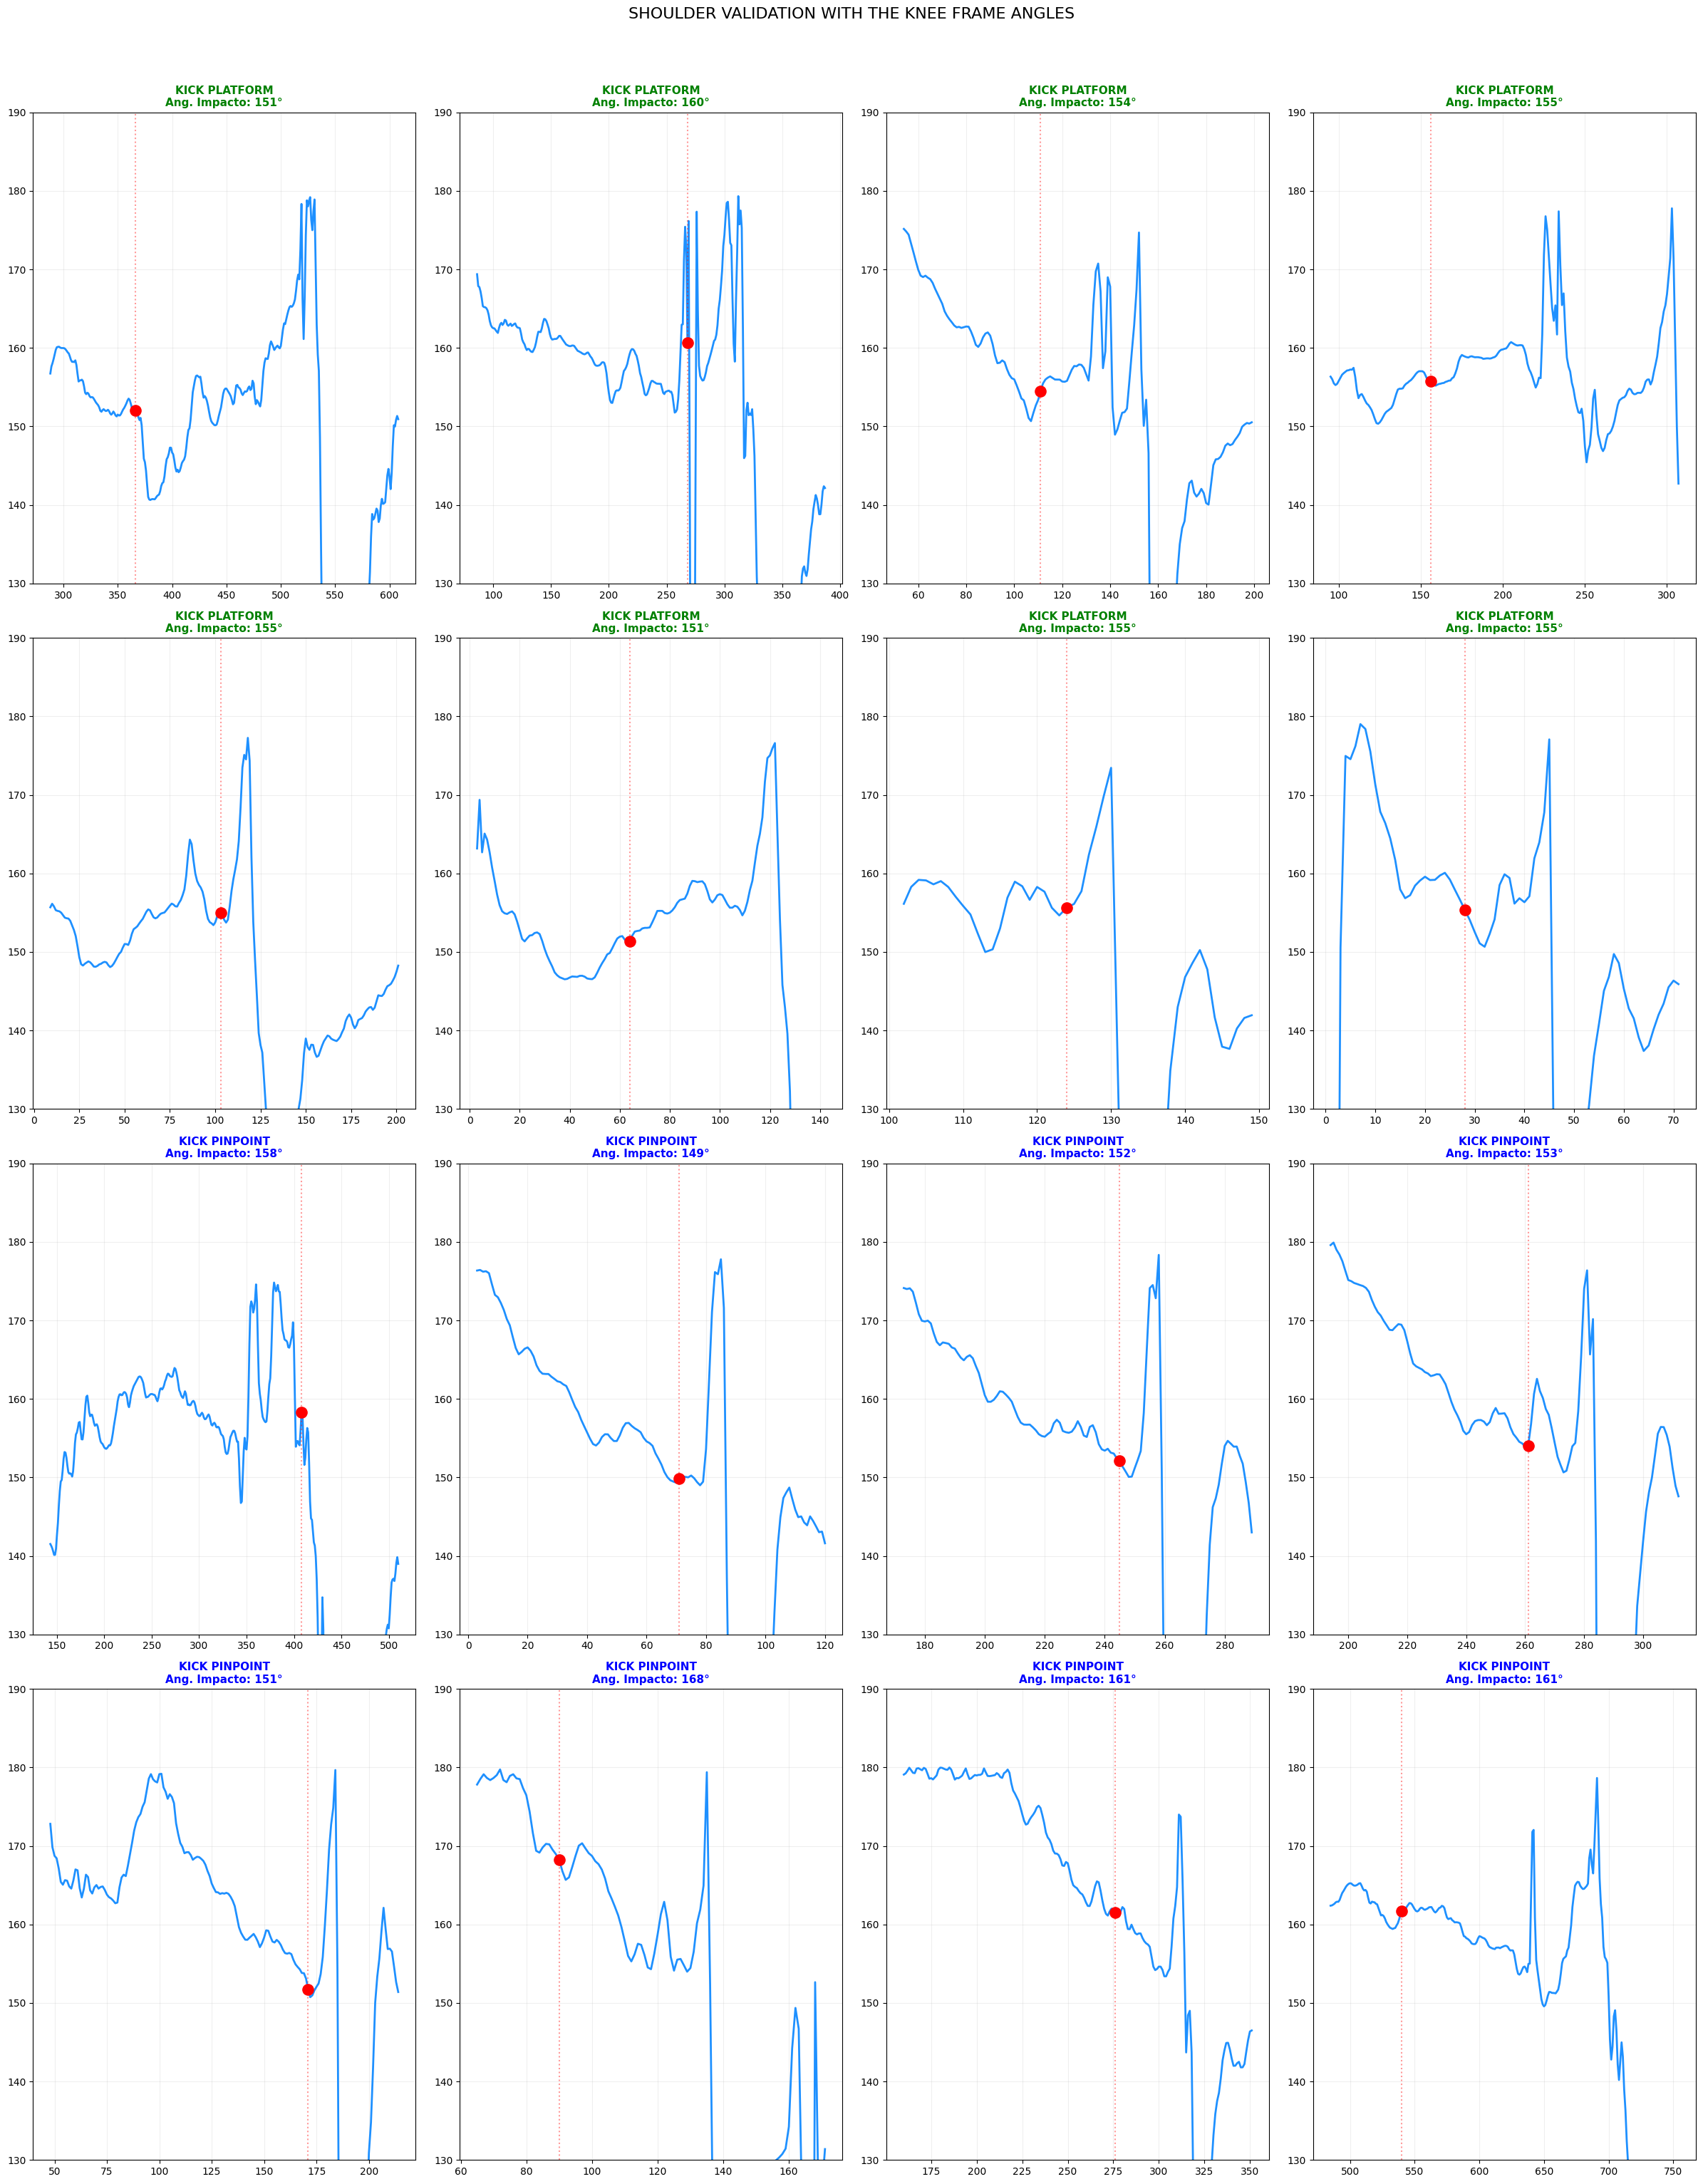

In [27]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(24, 30))
axes = axes.flatten()

for idx, file_path in enumerate(kick_files):
    df = pd.read_csv(file_path)
    # 1. Calcular Ángulos usando tu script modular
    angulos_izquierda = []
    for i in range(len(df)):
        l_hip = [df.loc[i, 'LEFT_HIP_x'], df.loc[i, 'LEFT_HIP_y']]
        l_knee = [df.loc[i, 'LEFT_KNEE_x'], df.loc[i, 'LEFT_KNEE_y']]
        l_ankle = [df.loc[i, 'LEFT_ANKLE_x'], df.loc[i, 'LEFT_ANKLE_y']]
        # Corrección: Uso del módulo geometry y nombre correcto de función
        angulos_izquierda.append(calculate_angles(l_hip, l_knee, l_ankle))
        
    df['angulo'] = angulos_izquierda
        
        # 2. Detectar Fases usando tu script modular
        # Corrección: Uso del módulo event_detector
    # 1. We calculate the angle phases of the knee
    start, min_f, max_f, target_f = detectar_fases_saque(df['angulo'])
    
    # 2. We calculate the shoulder metric during this window
    frames_x, angs_y, impact = analyze_shoulder_inclination(df, start, max_f)
        
    # 3. Dibujamos
    ax = axes[idx]
    typeof = "PINPOINT" if "pinpoint" in file_path.name.lower() else "PLATFORM"
    color_titulo = "blue" if typeof == "PINPOINT" else "green"
        
    # Ahora frames_x y angs_y tienen el mismo tamaño (ej. 193 y 193)
    ax.plot(frames_x, angs_y, color='dodgerblue', linewidth=2, label='Inclinación Torso')
        
        # Marcamos el impacto
    impact_idx = frames_x.index(impact)
    impact_angle = angs_y[impact_idx]
    ax.scatter(impact, impact_angle, color='red', s=120, zorder=5, label='Impacto')
        
        # Decoración
    ax.set_title(f"KICK {typeof}\nAng. Impacto: {int(impact_angle)}°", fontsize=11,color=color_titulo, fontweight='bold')
    ax.axvline(x=impact, color='red', linestyle=':', alpha=0.4)
    ax.set_ylim(130, 190)
    ax.grid(True, alpha=0.2)


plt.suptitle("SHOULDER VALIDATION WITH THE KNEE FRAME ANGLES", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

SLICE

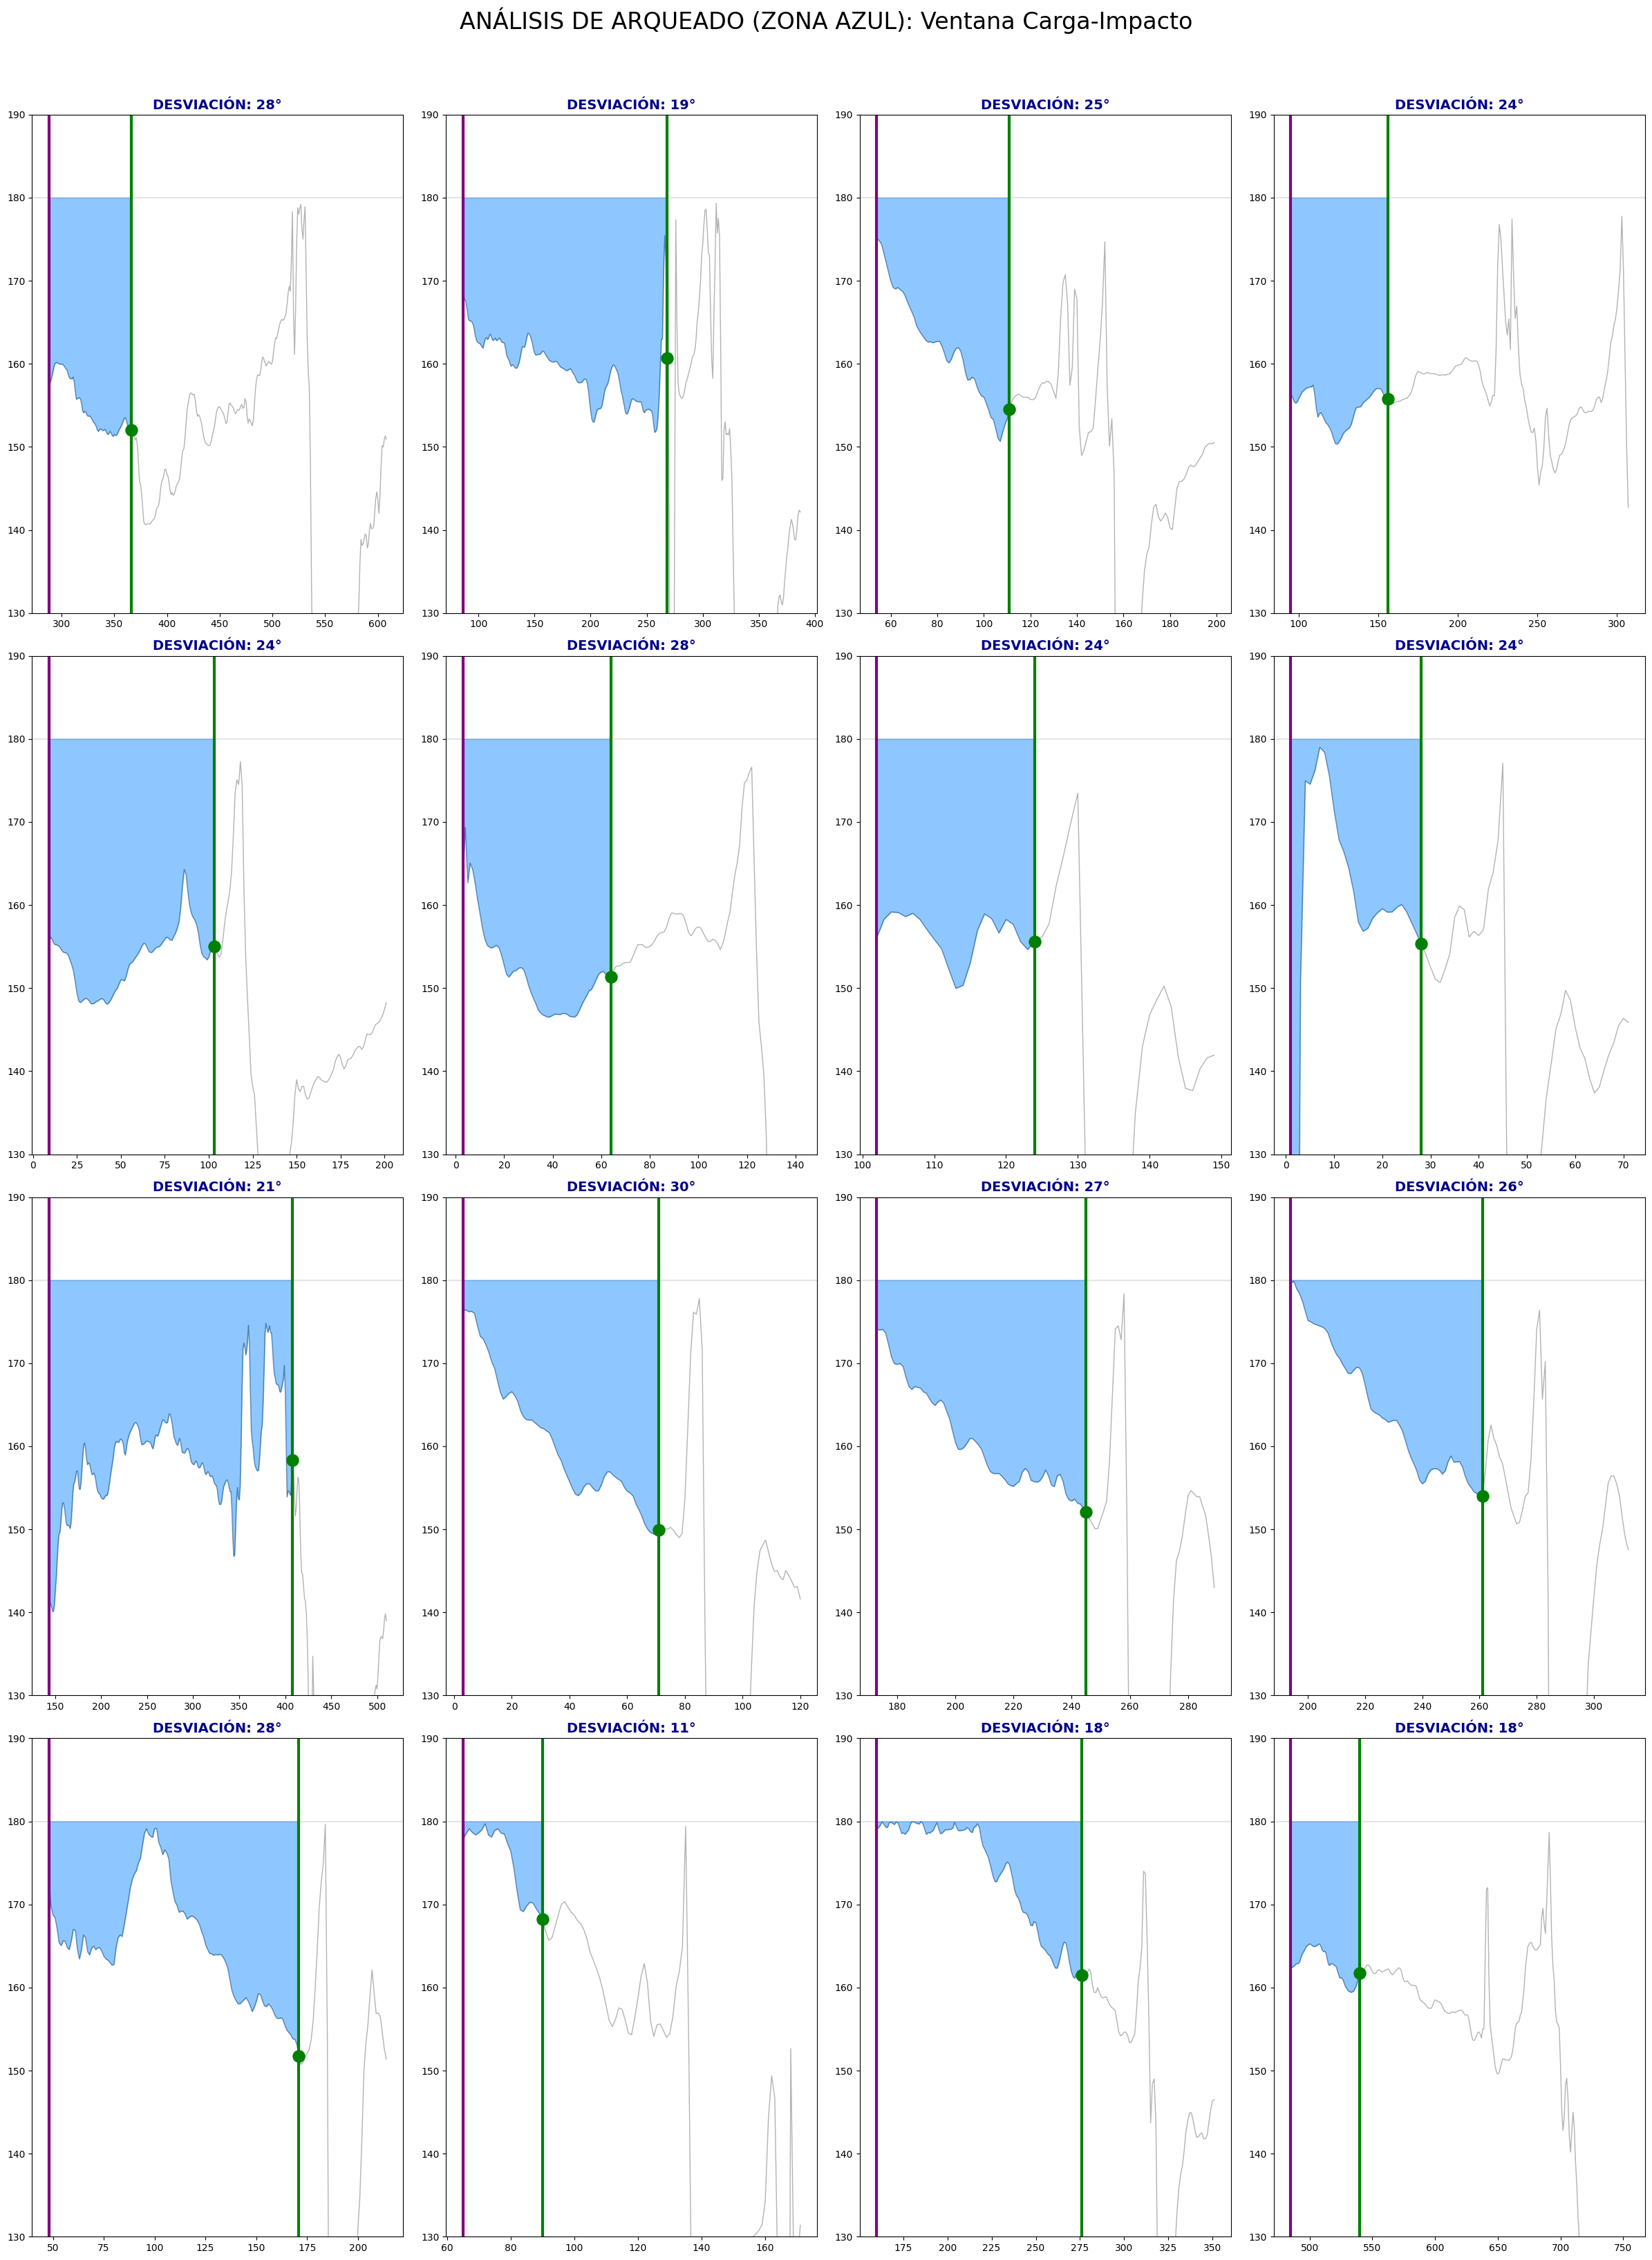

In [31]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(24, 32))
axes = axes.flatten()

for idx, file_path in enumerate(kick_files[:16]): 
    try:
        df = pd.read_csv(file_path)
        
        # 1. Fases de rodilla para marcar los límites temporales
        angles_knee = [calculate_angles(
            [row.LEFT_HIP_x, row.LEFT_HIP_y], 
            [row.LEFT_KNEE_x, row.LEFT_KNEE_y], 
            [row.LEFT_ANKLE_x, row.LEFT_ANKLE_y]
        ) for _, row in df.iterrows()] #
        
        start, min_f, max_f, target_f = detectar_fases_saque(angles_knee)
        frames_x, angs_y, impact = analyze_shoulder_inclination(df, start, max_f)
        
        if not frames_x or impact is None: continue
            
        ax = axes[idx]
        
        # --- ESTÉTICA SOLICITADA ---
        # 2. Línea base de verticalidad (180°)
        ax.axhline(y=180, color='gray', linestyle='-', alpha=0.2)
        
        # 3. Curva principal (Gris suave para no distraer)
        ax.plot(frames_x, angs_y, color='black', linewidth=1, alpha=0.3)
        
        # 4. BARRAS: Inicio (Morado) e Impacto (Verde)
        ax.axvline(x=start, color='purple', linestyle='-', linewidth=3, label='Inicio Carga')
        ax.axvline(x=impact, color='green', linestyle='-', linewidth=3, label='Impacto')
        
        # 5. EL INTERIOR: Sombreado azul SOLO entre las dos barras
        # Convertimos a array para poder filtrar por frames
        fx_arr = np.array(frames_x)
        ay_arr = np.array(angs_y)
        
        # Máscara para pintar solo el "hueco" entre las barras
        mask = (fx_arr >= start) & (fx_arr <= impact)
        
        ax.fill_between(fx_arr, ay_arr, 180, where=mask, 
                        color='dodgerblue', alpha=0.5, label='Zona de Arqueado')

        # Marcamos el punto de impacto en verde
        impact_idx = frames_x.index(impact)
        ax.scatter(impact, angs_y[impact_idx], color='green', s=150, zorder=5)
        
        # Título con el dato clave: cuántos grados se desvía
        desviacion = 180 - angs_y[impact_idx]
        ax.set_title(f"DESVIACIÓN: {int(desviacion)}°", fontsize=14, fontweight='bold', color='darkblue')
        
        ax.set_ylim(130, 190)
        ax.grid(False) # Quitamos la rejilla para que se vea más limpio el azul

    except Exception as e:
        print(f"Error en {file_path.name}: {e}")

plt.suptitle("ANÁLISIS DE ARQUEADO (ZONA AZUL): Ventana Carga-Impacto", fontsize=24, y=1.02)
plt.tight_layout()
plt.show()

KICK

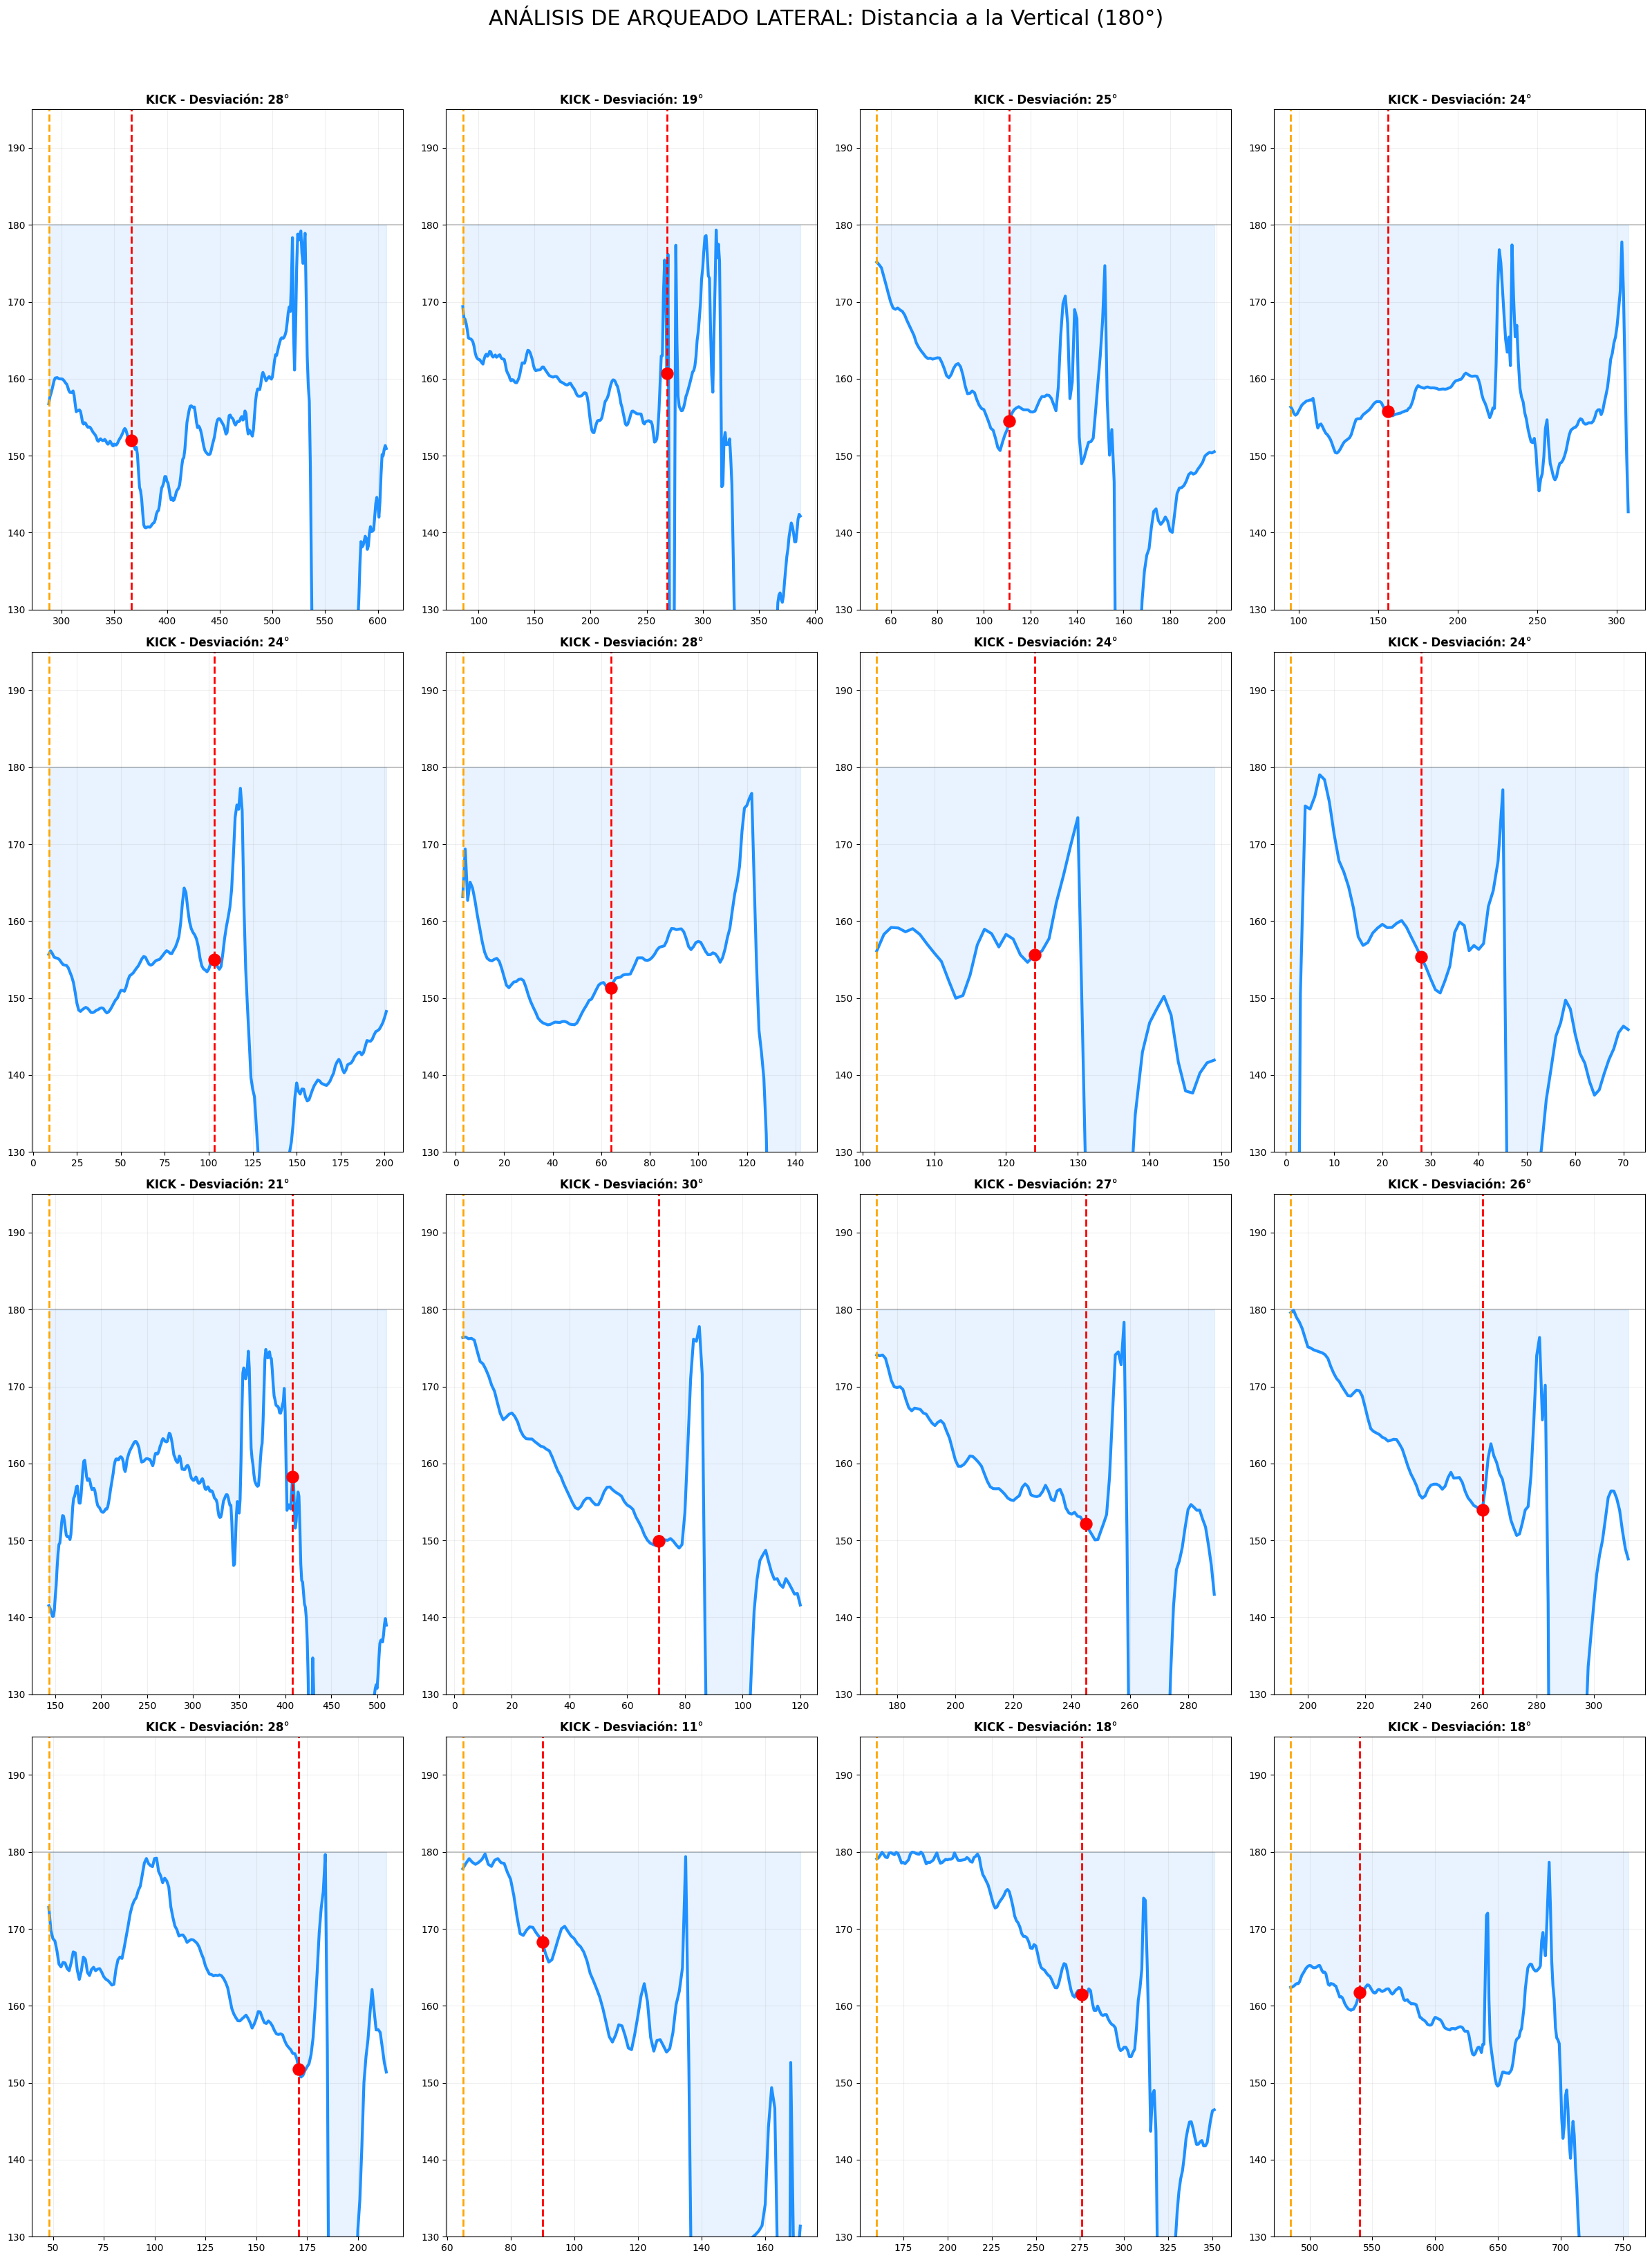

In [33]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(24, 32))
axes = axes.flatten()

for idx, file_path in enumerate(kick_files[:16]): 
    try:
        df = pd.read_csv(file_path)
        angles_knee = [calculate_angles(
            [row.LEFT_HIP_x, row.LEFT_HIP_y], 
            [row.LEFT_KNEE_x, row.LEFT_KNEE_y], 
            [row.LEFT_ANKLE_x, row.LEFT_ANKLE_y]
        ) for _, row in df.iterrows()]
        
        start, min_f, max_f, target_f = detectar_fases_saque(angles_knee)
        frames_x, angs_y, impact = analyze_shoulder_inclination(df, start, max_f)
        
        if not frames_x: continue
            
        ax = axes[idx]
        
        # 1. PINTAMOS LA LÍNEA DE REFERENCIA (Cuerpo totalmente vertical = 180°)
        ax.axhline(y=180, color='black', linestyle='-', alpha=0.2, label='Verticalidad')
        
        # 2. CURVA DE INCLINACIÓN
        ax.plot(frames_x, angs_y, color='dodgerblue', linewidth=3, label='Hombro')
        
        # 3. BARRAS DE FASES (Inicio y Fin de la ventana crítica)
        ax.axvline(x=start, color='orange', linestyle='--', linewidth=2, label='Inicio Carga')
        ax.axvline(x=impact, color='red', linestyle='--', linewidth=2, label='Impacto')
        
        # 4. RELLENO (Sombreado del arqueado)
        # Esto te ayuda a ver "cuánta área" hay de desviación
        ax.fill_between(frames_x, angs_y, 180, where=(np.array(angs_y) < 180), 
                        color='dodgerblue', alpha=0.1)

        # Localizar impacto
        impact_idx = frames_x.index(impact)
        impact_angle = angs_y[impact_idx]
        ax.scatter(impact, impact_angle, color='red', s=150, zorder=5)
        
        ax.set_title(f"KICK - Desviación: {int(180 - impact_angle)}°", fontsize=12, fontweight='bold')
        ax.set_ylim(130, 195)
        ax.grid(True, alpha=0.2)

    except Exception as e:
        print(f"Error en {file_path.name}: {e}")

plt.suptitle("ANÁLISIS DE ARQUEADO LATERAL: Distancia a la Vertical (180°)", fontsize=22, y=1.02)
plt.tight_layout()
plt.show()

# VAMOS A ANALIZAR EL ARQUEADO DE LA ESPALDA

FLAT

SLICE

KICK

# VAMOS A ANALIZAR EL ANGULO DE RODILLA

# VAMOS A ANALIZAR EL SALTO ENTRE LOS DIFERENTES EFECTOS

In [52]:
def calculate_max_jump(df, start, max_f):
    if start is None or target_f is None: return None
    
    df['hip_center_y'] = (df['LEFT_HIP_y'] + df['RIGHT_HIP_y']) / 2
    
    y_initial = df.loc[start, 'hip_center_y']
    window_jump = df.loc[start:max_f+10, 'hip_center_y']
    y_max = window_jump.min()
    
    hip_width = calculate_distance(
        [df.loc[start, 'LEFT_HIP_x'], df.loc[start, 'LEFT_HIP_y']],
        [df.loc[start, 'RIGHT_HIP_x'], df.loc[start, 'RIGHT_HIP_y']]
    )
       
    return (y_initial - y_max) / hip_width

In [53]:
flat_jumps = []
kick_jumps = []
slice_jumps = []

# Procesamos cada grupo (Asumiendo que tienes las listas de archivos filtradas)
for f in flat_files:
    df = pd.read_csv(f)
    start, min_f, max_f, target_f = calculate_knee_frame(df)
    flat_jumps.append(calculate_max_jump(df, start, max_f))

for f in kick_files:
    df = pd.read_csv(f)
    start, min_f, max_f, target_f = calculate_knee_frame(df)
    kick_jumps.append(calculate_max_jump(df, start, max_f))

for f in slice_files:
    df = pd.read_csv(f)
    start, min_f, max_f, target_f = calculate_knee_frame(df)
    slice_jumps.append(calculate_max_jump(df, start, max_f))


*VISUALIZATION*

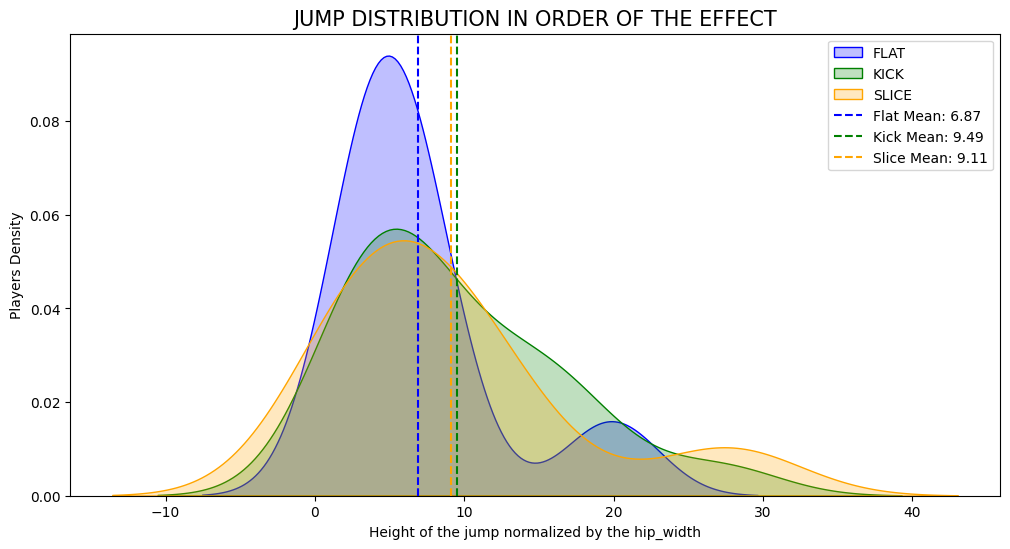

In [55]:
plt.figure(figsize=(12, 6))

# Histograms
sns.kdeplot(flat_jumps, fill=True, color="blue", label="FLAT", bw_adjust=1)
sns.kdeplot(kick_jumps, fill=True, color="green", label="KICK", bw_adjust=1)
sns.kdeplot(slice_jumps, fill=True, color="orange", label="SLICE", bw_adjust=1)

# We drawn the mean with vertical lines
plt.axvline(np.mean(flat_jumps), color='blue', linestyle='--', label=f'Flat Mean: {np.mean(flat_jumps):.2f}')
plt.axvline(np.mean(kick_jumps), color='green', linestyle='--', label=f'Kick Mean: {np.mean(kick_jumps):.2f}')
plt.axvline(np.mean(slice_jumps), color='orange', linestyle='--', label=f'Slice Mean: {np.mean(slice_jumps):.2f}')

plt.title("JUMP DISTRIBUTION IN ORDER OF THE EFFECT", fontsize=15)
plt.xlabel("Height of the jump normalized by the hip_width")
plt.ylabel("Players Density")
plt.legend()
plt.show()

# VAMOS A ANALIZAR LA MUÑECA RESPECTO A LA ESPALDA